In [1]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(tidyr)
library(ggsci)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
# 打印版本信息
packageVersion("Seurat")
packageVersion("dplyr")
packageVersion("ggplot2")
packageVersion("tidyr")
packageVersion("ggsci")
packageVersion("patchwork")  

[1] ‘5.1.0’

[1] ‘1.1.4’

[1] ‘3.5.1’

[1] ‘1.3.1’

[1] ‘3.2.0’

[1] ‘1.2.0’

# 1. 数据读取

In [3]:
test_T1 = './T1_test_feature_bc_matrix/'
test_T2 = './T2_test_feature_bc_matrix/'

In [4]:
t1 <- Read10X(data.dir = test_T1, gene.column = 1)
t2<- Read10X(data.dir = test_T2, gene.column = 1)

In [5]:
# 加载 Part 1 导出的过滤后的barcode信息
t1_bc <- read.csv('./Results/T1_barcodes.csv')
t2_bc <- read.csv('./Results/T2_barcodes.csv')

In [6]:
# 对细胞进行过滤
t1_mtx <- t1[,colnames(t1) %in% t1_bc$barcode]
t2_mtx <- t2[,colnames(t2) %in% t2_bc$barcode]
dim(t1_mtx)
dim(t2_mtx)

[1] 33437   992

[1] 33437   958

In [7]:
# 检查顺序一致性 (如果顺序不一致，identical 会返回 FALSE，但不影响分析)
identical(colnames(t1_mtx),t1_bc$barcode)
identical(colnames(t2_mtx),t2_bc$barcode)

[1] TRUE

[1] TRUE

In [8]:
# 避免分析多个样本发生合并冲突，添加样本前缀
colnames(t1_mtx) <- paste0('T1','_',colnames(t1_mtx))
colnames(t2_mtx) <- paste0('T2','_',colnames(t2_mtx))
head(colnames(t1_mtx))
head(colnames(t2_mtx))

[1] "T1_CACTAAGAGGTCACCC-1" "T1_GTCTCACCAGAGGTAC-1" "T1_TACCCACGTCGCAACC-1"
[4] "T1_TGATCAGAGCGAATGC-1" "T1_GTAGATCTCCGTGACG-1" "T1_CATCAAGCAGCTGCCA-1"

[1] "T2_ATTACTCTCTAGGAAA-1" "T2_GCCAGGTAGTGAATAC-1" "T2_GGGTAGATCACACCGG-1"
[4] "T2_TACGGGCCAAACAGGC-1" "T2_GATGGAGCATCCGTGG-1" "T2_CAACAGTGTACGACTT-1"

# 2. 创建 Seurat 对象

In [9]:
# 创建 Seurat 对象
sc_t1 <- CreateSeuratObject(t1_mtx,min.cells = 5,min.features = 200)
sc_t1
head(sc_t1,3)

An object of class Seurat 
14834 features across 982 samples within 1 assay 
Active assay: RNA (14834 features, 0 variable features)
 1 layer present: counts

,orig.ident,nCount_RNA,nFeature_RNA
,<fct>,<dbl>,<int>
T1_CACTAAGAGGTCACCC-1,T1,849,434
T1_GTCTCACCAGAGGTAC-1,T1,860,571
T1_TACCCACGTCGCAACC-1,T1,1916,1235


In [10]:
sc_t2 <- CreateSeuratObject(t2_mtx,min.cells = 5,min.features = 200)
sc_t2
head(sc_t2,3)

An object of class Seurat 
15045 features across 953 samples within 1 assay 
Active assay: RNA (15045 features, 0 variable features)
 1 layer present: counts

,orig.ident,nCount_RNA,nFeature_RNA
,<fct>,<dbl>,<int>
T2_ATTACTCTCTAGGAAA-1,T2,637,500
T2_GCCAGGTAGTGAATAC-1,T2,1065,774
T2_GGGTAGATCACACCGG-1,T2,3326,1849


In [11]:
# 合并所有单细胞对象，并标记各样本下
sc <- merge(sc_t1,c(sc_t2))
sc

An object of class Seurat 
15994 features across 1935 samples within 1 assay 
Active assay: RNA (15994 features, 0 variable features)
 2 layers present: counts.1, counts.2

In [12]:
# 样本信息
sc@meta.data$sample <- sc@meta.data$orig.ident
table(sc@meta.data$sample)


 T1  T2 
982 953 

# 3. 线粒体占比计算与可视化

In [13]:
# 导入线粒体注释文件 (确保该文件已在 ./Results/ 目录下)
tilapia_id_name <- read.delim("./Results/oni2zebra.txt", h = T, sep = "\t")
head(tilapia_id_name)

,Gene.stable.ID,Gene.name
,<chr>,<chr>
1,ENSONIG00000000001,PPFIBP1
2,ENSONIG00000000002,SYT10
3,ENSONIG00000000003,SYT1
4,ENSONIG00000000005,PPP1R12A
5,ENSONIG00000000006,RPS16
6,ENSONIG00000000007,MYF6


In [14]:
mt.trRNA.id <- tilapia_id_name[grep("^MT-|mt-",tilapia_id_name$Gene.name),]$Gene.stable.ID
mt.trRNA.id

[1] "ENSONIG00000027258" "ENSONIG00000027747" "ENSONIG00000028626"
 [4] "ENSONIG00000028837" "ENSONIG00000030924" "ENSONIG00000033663"
 [7] "ENSONIG00000035077" "ENSONIG00000036728" "ENSONIG00000036904"
[10] "ENSONIG00000038509" "ENSONIG00000042515" "ENSONIG00000042622"
[13] "ENSONIG00000042655"

In [15]:
mt.trRNA.gene <- tilapia_id_name[grep("^MT-|mt-",tilapia_id_name$Gene.name),]
mt.trRNA.gene

,Gene.stable.ID,Gene.name
,<chr>,<chr>
15713,ENSONIG00000027258,MT-ND5
15937,ENSONIG00000027747,MT-ND3
16326,ENSONIG00000028626,MT-ND6
16414,ENSONIG00000028837,mt-atp8
17317,ENSONIG00000030924,MT-ND4
18519,ENSONIG00000033663,MT-ATP6
19147,ENSONIG00000035077,MT-ND2
19888,ENSONIG00000036728,MT-CO1
19956,ENSONIG00000036904,MT-CO2


In [16]:
# 提取线粒体基因 ID
mt.genes <- tilapia_id_name$Gene.stable.ID[
  grepl("^MT-|^mt-", tilapia_id_name$Gene.name, ignore.case = TRUE)
]
mt.genes

[1] "ENSONIG00000027258" "ENSONIG00000027747" "ENSONIG00000028626"
 [4] "ENSONIG00000028837" "ENSONIG00000030924" "ENSONIG00000033663"
 [7] "ENSONIG00000035077" "ENSONIG00000036728" "ENSONIG00000036904"
[10] "ENSONIG00000038509" "ENSONIG00000042515" "ENSONIG00000042622"
[13] "ENSONIG00000042655"

In [17]:
# 计算线粒体占比
sc[["percent.mt"]] <- PercentageFeatureSet(sc, features = intersect(rownames(sc), mt.genes))

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”


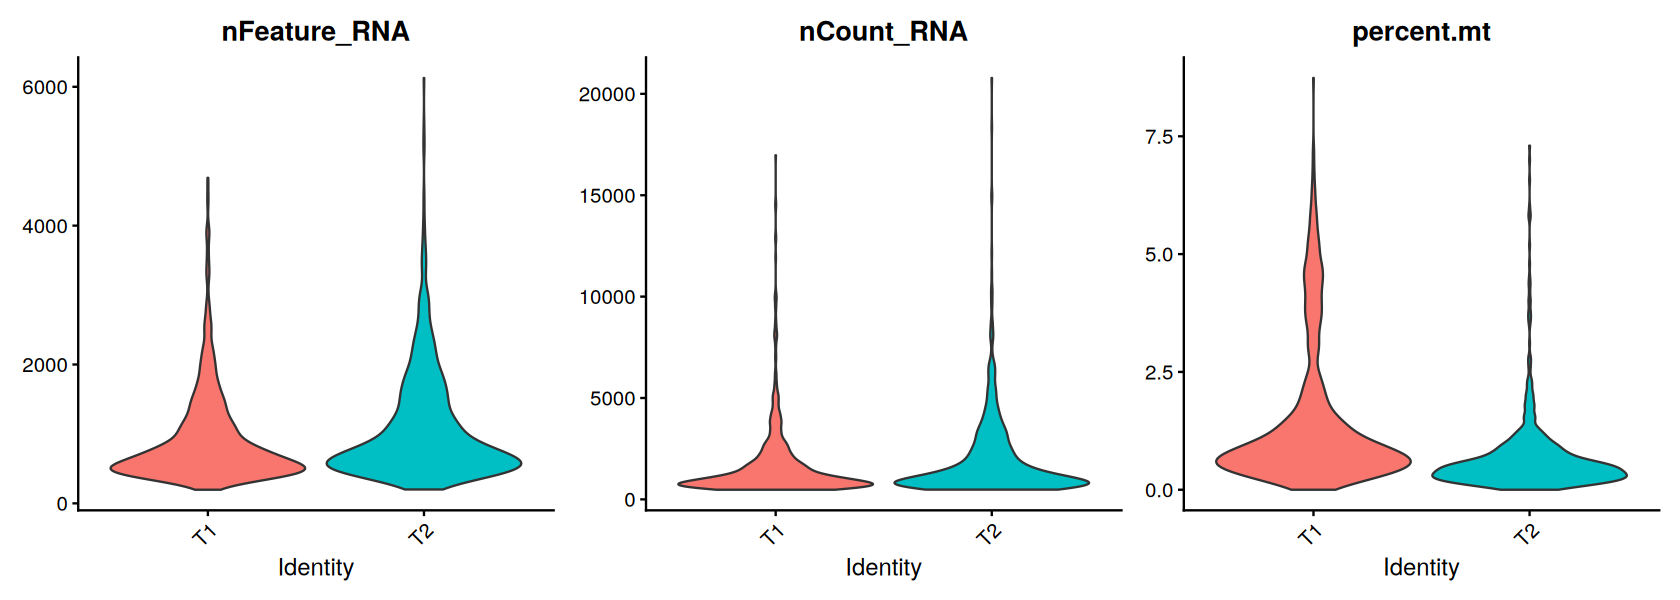

In [18]:
# 质控指标可视化
options(repr.plot.width = 14,repr.plot.height = 5)
VlnPlot(sc, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3,group.by = 'orig.ident',pt.size = 0)

# 4. 保存经过初筛的结果

In [19]:
saveRDS(sc, './Results/Test_Tilapia_Unfiltered.rds')
cat("Successfully saved Seurat object to ./Results/ \n")

Successfully saved Seurat object to ./Results/ 


In [20]:
head(sc)

,orig.ident,nCount_RNA,nFeature_RNA,sample,percent.mt
,<chr>,<dbl>,<int>,<chr>,<dbl>
T1_CACTAAGAGGTCACCC-1,T1,849,434,T1,5.8892815
T1_GTCTCACCAGAGGTAC-1,T1,860,571,T1,0.5813953
T1_TACCCACGTCGCAACC-1,T1,1916,1235,T1,1.0960334
T1_TGATCAGAGCGAATGC-1,T1,501,355,T1,1.3972056
T1_GTAGATCTCCGTGACG-1,T1,794,598,T1,0.5037783
T1_CATCAAGCAGCTGCCA-1,T1,706,550,T1,0.2832861
T1_CATGCCTTCTGTCCGT-1,T1,1034,784,T1,0.5802708
T1_TAGGGTTCATTCACAG-1,T1,939,714,T1,0.6389776
T1_CGCGTGAAGCAAGTCG-1,T1,657,455,T1,0.7610350


In [21]:
sc

An object of class Seurat 
15994 features across 1935 samples within 1 assay 
Active assay: RNA (15994 features, 0 variable features)
 2 layers present: counts.1, counts.2